In [ ]:
!pip install -qU langchain==0.3.25 langchain-openai==0.3.22 langchain-experimental==0.3.4 numexpr==2.11.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.4/403.4 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.9/458.9 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.0/363.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.6/948.6 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [1]:
OPENROUTER_TOKEN = ""

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
    model="stepfun/step-3.5-flash:free"
)

print(llm.invoke("Привет! Как твои дела?").content)

Привет! Спасибо, что спрашиваешь 😊  
Как AI-ассистент, у меня нет эмоций или «дел» в человеческом понимании, но я всегда готов помочь с вопросами, задачами или просто пообщаться!  

А у тебя как? Чем могу быть полезен?


### **LangChain ReActAgent**

**Travel Assistant с памятью**

Пользователь говорит страну / город / бюджет / валюту, а агент сам решает, какой tool вызвать.
Агент помнит предыдущие сообщения
и выдает полезную travel-сводку.

Реалировано 3 инструмента:

* country_info_tool
* currency_tool
* final_answer


In [ ]:
import requests

from langchain.memory import ConversationBufferMemory
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage

In [ ]:
@tool
def country_info_tool(country_name: str) -> str:
    """
    Получает краткую информацию о стране:
    столица, регион, население, языки, валюты.
    """
    url = f"https://restcountries.com/v3.1/name/{country_name}"
    response = requests.get(url)

    if response.status_code != 200:
        return f"Не удалось найти информацию по стране: {country_name}"

    data = response.json()
    if not data:
        return f"Не удалось найти информацию по стране: {country_name}"

    country = data[0]

    name = country.get("name", {}).get("common", country_name)
    capital = country.get("capital", "не указана")[0]
    region = country.get("region", "не указан")
    population = country.get("population", "не указано")

    languages_dict = country.get("languages", {})
    languages = ", ".join(languages_dict.values()) if languages_dict else "не указаны"

    currencies_dict = country.get("currencies", {})
    if currencies_dict:
        currencies = []
        for code, info in currencies_dict.items():
            cur_name = info.get("name", code)
            symbol = info.get("symbol", "")
            currencies.append(f"{cur_name} ({code}, {symbol})")
        currencies = ", ".join(currencies)
    else:
        currencies = "не указаны"

    return (
        f"Страна: {name}\n"
        f"Столица: {capital}\n"
        f"Регион: {region}\n"
        f"Население: {population}\n"
        f"Языки: {languages}\n"
        f"Валюты: {currencies}"
    )

In [ ]:
@tool
def currency_tool(amount: float, from_currency: str, to_currency: str) -> str:
    """
    Конвертирует сумму из одной валюты в другую.
    Используй этот tool, когда пользователь просит пересчитать бюджет.
    """

    from_currency = from_currency.upper().strip()
    to_currency = to_currency.upper().strip()

    url = f"https://open.er-api.com/v6/latest/{from_currency}"
    response = requests.get(url)

    if response.status_code != 200:
        return f"Не удалось получить курс для валюты {from_currency}"

    data = response.json()
    rates = data.get("rates", {})

    if to_currency not in rates:
        return f"Не найден курс для валюты {from_currency}"

    converted = amount * rates[to_currency]
    rate = rates[to_currency]

    return (
        f"{amount:.2f} {from_currency} = {converted:.2f} {to_currency}. "
        f"Текущий курс: 1 {from_currency} = {rate:.4f} {to_currency}"
    )

In [ ]:
@tool
def final_answer(answer: str, tools_used: list[str]) -> dict:
    """
    Используется только для финального ответа пользователю.
    """
    return {"answer": answer, "tools_used": tools_used}

In [ ]:
tools = [country_info_tool, currency_tool, final_answer]

In [ ]:
memory = ConversationBufferMemory(
    memory_key="chat_history",
    return_messages=True
)

/tmp/ipykernel_5245/515166408.py:1: LangChainDeprecationWarning: Please see the migration guide at: https://python.langchain.com/docs/versions/migrating_memory/
  memory = ConversationBufferMemory(


In [ ]:
agent_prompt = ChatPromptTemplate.from_messages([
    ("system",(
            "Ты - travel-ассистент."
            "Отвечай только на русском языке."
            "Ты помогаешь пользователю быстро собрать полезную информацию перед поездкой."
            "Если нужно узнать сведения о стране, то используй country_info_tool."
            "Если нужно пересчитать бюджет, то используй currency_tool."
            "Когда информации достаточно, обязательно заверши ответ через tool final_answer."
            "Учитывай предыдущие сообщения пользователя из истории."
            "Если страна не найдена, то сообщи об этом."
            "Финальный ответ должен быть читаемым текстом."
        )),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="scratchpad"),
])

In [ ]:
agent = agent_prompt | llm.bind_tools(tools, tool_choice="auto")

In [ ]:
class TravelReActAgent:
    def __init__(self, llm_agent, tools, memory, max_steps: int = 5):
        self.agent = llm_agent
        self.tools = {tool.name: tool for tool in tools}
        self.memory = memory
        self.max_steps = max_steps

    def invoke(self, user_input: str) -> str:
        chat_history = self.memory.load_memory_variables({}).get("chat_history", [])
        scratchpad = []

        for step in range(self.max_steps):
            response = self.agent.invoke({
                "input": user_input,
                "chat_history": chat_history,
                "scratchpad": scratchpad})

            if not response.tool_calls:
                final_text = response.content
                self.memory.save_context(
                    {"input": user_input},
                    {"output": final_text})
                return final_text

            scratchpad.append(response)

            for tool_call in response.tool_calls:
              tool_name = tool_call["name"]
              tool_args = tool_call["args"]

            if tool_name not in self.tools:
                final_text = f"Ошибка: неизвестный инструмент {tool_name}"
                self.memory.save_context(
                    {"input": user_input},
                    {"output": final_text})
                return final_text

            tool_result = self.tools[tool_name].invoke(tool_args)

            scratchpad.append(ToolMessage(
                    content=str(tool_result),
                    tool_call_id=tool_call["id"]))

            if tool_name == "final_answer":
                if isinstance(tool_result, dict):
                    final_text = tool_result["answer"]
                else:
                    final_text = str(tool_result)

                self.memory.save_context(
                    {"input": user_input},
                    {"output": final_text})
                return final_text

        final_text = "Не удалось завершить."
        self.memory.save_context(
            {"input": user_input},
            {"output": final_text})
        return final_text

In [ ]:
travel_agent = TravelReActAgent(llm_agent=agent,
    tools=tools,
    memory=memory)

In [ ]:
print(travel_agent.invoke("Я собираюсь в Китай. Расскажи про эту страну для моей поездки и пересчитай мой бюждет 100000 рублей в местную валюту."))

**Китай — путешествие:**

**Основная информация о стране:**
- **Столица:** Пекин
- **Регион:** Восточная Азия
- **Население:** около 1,4 миллиарда человек
- **Официальные языки:** Китайский (путунхуа)
- **Валюта:** Китайский юань (CNY)

**Ваш бюджет:**
100 000 российских рублей = 8 490 китайских юаней (по текущему курсу 1 RUB = 0.0849 CNY)

**Полезные советы:**
- Китай — огромная страна с разнообразными климатами и культурами. Основные туристические направления: Пекин (Запретный город, Великая стена), Шанхай (современная архитектура), Гонконг, Синьцзян (горы и пустыни).
- Лучшее время для посещения — весна (апрель-май) и осень (сентябрь-октябрь) из-за комфортной погоды.
- Обязательно попробуйте региональную кухню, которая сильно отличается в разных провинциях.
- Для передвижения по стране удобно пользоваться высокоскоростными поездами.
- Учитывая бюджет около 8500 CNY, вы можете комфортно провести 1-2 недели, в зависимости от стиля путешествия (хостels, общественный транспорт, еда на у

In [ ]:
print(travel_agent.invoke("А теперь кратко напомни, что ты уже узнал про мою поездку."))

**Краткое напоминание о вашей поездке:**

- **Направление:** Китай
- **Валюта:** Китайский юань (CNY)
- **Бюджет:** 100 000 рублей ≈ 8 490 юаней
- **Основные факты:** Пекин — столица, основной язык — китайский, население ~1,4 млрд.
- **Совет:** Учитывая бюджет, планируйте на 1–2 недели с доступным жильём и транспортом.


In [ ]:
print(travel_agent.invoke("Также хочу поехать в страну Пызсзвзазм, расскажи про нее"))

**Страна "Пызсзвзазм" не найдена.** Возможно, в названии есть опечатка? Уточните, пожалуйста, правильное название страны, и я с радостью предоставлю информацию.


### **LangGraph Agent**

**Агент советчик по погоде**

Пользователь говорит город, активность и время, а агент дает совет по погоде, что лучше надеть, и стоит ли совершать эту активность.

Граф будет содержать такие ноды:

* parse_query_node — достает город, дату, тип активности.

* geocode_node — находит координаты города через geocoding API.

* weather_api_node — получает прогноз по часам/дням.

* analysis_node — вытаскивает осадки, ветер, температуру.

* llm_summary_node — превращает это в человеческий совет.

In [ ]:
!pip install langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 13.3 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.83
    Uninstalling langchain-core-0.3.83:
      Successfully uninstalled langchain-core-0.3.83
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.25 requires langchain-core<1.0.0,>=0.3.58, but you have langchain-core 1.2.23 which is incompatible.
langchain-openai 0.3.22 requires langchain-core<1.0.0,>=0.3.64, but you have langchain-core 1.2.23 which is incompatible.
langchain-community 0.3.25 requires langchain-core<1.0.0,>=0.3.65, but you have langchain-core 1.2.23 which is incompatible.
langchain-experimental 0.3.4 requires langchain-core<0.4.0,>=0.3.28, but you have langchain-core 1.2.23 which is incompatible.


In [ ]:
from typing import TypedDict, Optional, Dict, Any
from langgraph.graph import StateGraph, START, END

In [ ]:
class WeatherState(TypedDict, total=False):
    user_query: str
    city: str
    activity: str
    latitude: float
    longitude: float
    weather_raw: Dict[str, Any]
    weather_summary: str
    final_answer: str
    error: str

In [ ]:
def parse_query_node(state: WeatherState) -> WeatherState:
    user_query = state["user_query"]

    prompt = f"""Извлеки из запроса пользователя город и вид активности.
    Верни ответ строго в формате:
    city=...
    activity=...
    Запрос пользователя:
    {user_query}
    """

    response = llm.invoke(prompt).content.strip()

    city = ""
    activity = ""

    for line in response.splitlines():
        if line.lower().startswith("city="):
            city = line.split("=", 1)[1].strip()
        elif line.lower().startswith("activity="):
            activity = line.split("=", 1)[1].strip()

    if not city:
        return {"error": "Не удалось определить город."}

    if not activity:
        activity = "обычная прогулка"

    return {
        "city": city,
        "activity": activity
    }

In [ ]:
def geocode_node(state: WeatherState) -> WeatherState:
    if state.get("error"):
        return state

    city = state["city"]

    url = "https://geocoding-api.open-meteo.com/v1/search"
    params = {
        "name": city,
        "count": 1,
        "language": "ru",
        "format": "json"
    }

    response = requests.get(url, params=params, timeout=20)
    if response.status_code != 200:
        return {"error": f"Ошибка API для города {city}"}

    data = response.json()
    results = data.get("results", [])

    if not results:
        return {"error": f"Город {city} не найден"}

    place = results[0]
    return {
        "latitude": place["latitude"],
        "longitude": place["longitude"],
        "city": place["name"]
    }

In [ ]:
def weather_api_node(state: WeatherState) -> WeatherState:
    if state.get("error"):
        return state

    lat = state["latitude"]
    lon = state["longitude"]

    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "current": "temperature_2m,apparent_temperature,wind_speed_10m,precipitation",
        "timezone": "auto"
    }

    response = requests.get(url, params=params, timeout=20)
    if response.status_code != 200:
        return {"error": "Ошибка API погоды"}

    data = response.json()
    return {
        "weather_raw": data
    }

In [ ]:
def summarize_weather_node(state: WeatherState) -> WeatherState:
    if state.get("error"):
        return state

    current = state["weather_raw"].get("current", {})

    temp = current.get("temperature_2m", "неизвестно")
    apparent = current.get("apparent_temperature", "неизвестно")
    wind = current.get("wind_speed_10m", "неизвестно")
    precipitation = current.get("precipitation", "неизвестно")

    summary = (
        f"Город: {state['city']}\n"
        f"Температура: {temp}°C\n"
        f"Ощущается как: {apparent}°C\n"
        f"Ветер: {wind} м/с\n"
        f"Осадки: {precipitation} мм\n"
        f"Активность пользователя: {state['activity']}")

    return {
        "weather_summary": summary}

In [ ]:
def llm_recommendation_node(state: WeatherState) -> WeatherState:
    if state.get("error"):
        return {
            "final_answer": f"Не удалось обработать запрос: {state['error']}"
        }

    prompt = f"""
Ты - помощник, который советует, подходит ли погода для активности на основе этих данных:
{state['weather_summary']}

Сделай естественный и не слишком длинный ответ на русском языке:
* подходит ли погода для активности
* что стоит учесть
* что надеть или взять с собой
"""

    final_answer = llm.invoke(prompt).content
    return {
        "final_answer": final_answer
    }

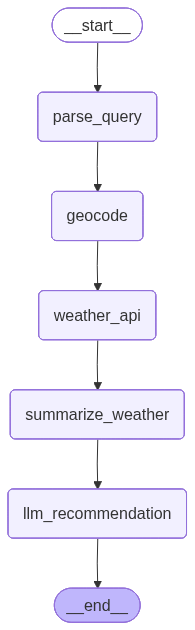

In [ ]:
graph_builder = StateGraph(WeatherState)

graph_builder.add_node("parse_query", parse_query_node)
graph_builder.add_node("geocode", geocode_node)
graph_builder.add_node("weather_api", weather_api_node)
graph_builder.add_node("summarize_weather", summarize_weather_node)
graph_builder.add_node("llm_recommendation", llm_recommendation_node)

graph_builder.add_edge(START, "parse_query")
graph_builder.add_edge("parse_query", "geocode")
graph_builder.add_edge("geocode", "weather_api")
graph_builder.add_edge("weather_api", "summarize_weather")
graph_builder.add_edge("summarize_weather", "llm_recommendation")
graph_builder.add_edge("llm_recommendation", END)

weather_graph = graph_builder.compile()
weather_graph

In [ ]:
result = weather_graph.invoke({
    "user_query": "Можно ли сейчас сходить на пробежку в Москве?"})

print(result["final_answer"])

Погода для пробежки в Москве **терпимая, но прохладная**. Температура около +7°C при ощутимом +4°C из-за ветра — не мороз, но гарантировано chilly.

**Что стоит учесть:**
- Ветер 4.8 м/с создаёт ощутимую прохладу, особенно на открытых участках и поворотах.
- Проверьте, нет ли скользких участков (после заморозков или если были осадки ранее).
- Разминку лучше сделать в помещении, чтобы начать пробежку уже разогретым.

**Что надеть:**
- Многослойность: термобельё, лёгкий флисовый или ветрозащитный верх.
- Обязательно шапка (или головной убор) и перчатки — руки и голова сильно мерзнут.
- Длинные штаны или компрессионные гетры.
- Обувь с хорошим сцеплением, чтобы не поскользнуться.

Если вы привыкли к прохладе — вполне комфортно. Если нет, лучше утепляться сильнее. Главное — не перегреться в начале!


In [ ]:
result = weather_graph.invoke({
    "user_query": "Подойдет ли погода в Санкт-Петербурге для прогулки с собакой?"})

print(result["final_answer"])

Для прогулки в Санкт-Петербурге сегодня погода **не очень комфортная, но возможна**, если правильно подготовиться.

**Что важно учесть:**
*   **Сильный ветер (10.4 м/с)** — это главная проблема. Он создаёт ощущение холода (температура "как 1.4°C") и может быть惠ким, особенно на открытых площадках, у воды и на мостах.
*   Несмотря на отсутствие осадков, в Petersbug часто сыро, поэтому влажность может усилить ощущение прохлады.

**Что надеть/взять:**
*   **Обязательно**Windproof-ветрозащитная верхняя одежда (дождевик, куртка с капюшоном или на молнию).
*   **Тёплый слой** под ветрозащиту: свитер, флисовая кофта.
*   **Шапка** (значительная часть тепла уходит через голову) и **шарф** (можно защитить лицо от ветра).
*   **Удобная, непромокаемая обувь** и тёплые носки.
*   Можно взять **запасные перчатки** на случай, если верхние намокнут от сырости.

**Итог:** Прогулка в парках с укрытиями (например, в Суворовском сквере или на Елагином острове) будет приятнее, чем по открытым набережным. О